# Analysis of contral data sample

- 30 days of simulation
- two configurations, but the same LLM model *Qwen/Qwen3-VL-8B-Instruct*

Data presents approximated behaviour of LLM combined with configurations. Selected LLM not always returns response in correct format, what disturbs behaviour of agents.

In [1]:
from social_graph.pipeline import *
from social_graph.metrics import *

In [2]:
conn_1 = sqlite3.connect('data/control_sample/database_config_1.db')
conn_2 = sqlite3.connect('data/control_sample/database_config_2.db')

In [3]:
print("Configuration 1:")
users_1, follow_1, posts_1 = load_data_and_describe_network(conn_1)
print("Configuration 2:")
users_2, follow_2, posts_2 = load_data_and_describe_network(conn_2)

Configuration 1:
Number of users: 1000
Total actions: 5062
Follow actions: 4944
Unfollow actions: 118
Number of rounds: 31
Number of posts: 48210

Configuration 2:
Number of users: 1000
Total actions: 3348
Follow actions: 3292
Unfollow actions: 56
Number of rounds: 31
Number of posts: 38455



In [4]:
print("Configuration 1:")
G_1, G_lcc_1 = create_graph(follow_1)
print("Configuration 2:")
G_2, G_lcc_2 = create_graph(follow_2)

Configuration 1:
Number of nodes: 810
Number of edges: 4822
Number of connective components: 6
Components sizes: [800, 3, 2, 1, 2, 2]
Number of nodes (LCC): 800
Number of edges (LCC): 4817
Configuration 2:
Number of nodes: 800
Number of edges: 3238
Number of connective components: 2
Components sizes: [798, 2]
Number of nodes (LCC): 798
Number of edges (LCC): 3237


In [5]:
def calculate_global_metrics(G, G_lcc, label='Simulation'):
    """
    Calculates global metrics for graph and prints them. Some metrics require connected graph.
    :param G: Graph
    :param G_lcc: Largest connected component of G
    :return: table of global metrics
    """
    avg_deg = sum(dict(G.degree()).values()) / G.number_of_nodes()
    dens = nx.density(G)

    # largest connected component -> diameter !!!
    diam = nx.diameter(G_lcc.to_undirected())  # Longest shortest path between any two nodes
    print(f"Mean degree: {avg_deg:.2f}\nDensity: {dens:.4f}\nDiameter: {diam}")

    avg_short_path = nx.average_shortest_path_length(G_lcc.to_undirected())
    print(f"Avg. shortest path: {avg_short_path:.3f}")

    ig_graph = ig.Graph.TupleList(G.edges(), directed=True)
    partition = la.find_partition(ig_graph, partition_type=la.ModularityVertexPartition, seed=42)
    modularity = partition.modularity
    print(f"Modularity score: {modularity:.3f}")

    metrics = pd.DataFrame({
        'Metric': ['Mean degree', 'Density', 'Diameter', 'Avg. shortest path', 'Modularity'],
        label: [avg_deg, dens, diam, avg_short_path, modularity]
    })

    return metrics

In [6]:
print("Configuration 1:")
metrics_1 = calculate_global_metrics(G_1, G_lcc_1)
print("Configuration 2:")
metrics_2 = calculate_global_metrics(G_2, G_lcc_2)

Configuration 1:
Mean degree: 11.91
Density: 0.0074
Diameter: 7
Avg. shortest path: 3.225
Modularity score: 0.258
Configuration 2:
Mean degree: 8.10
Density: 0.0051
Diameter: 8
Avg. shortest path: 3.411
Modularity score: 0.328


In [7]:
metrics_1

,Metric,Simulation
0,Mean degree,11.906173
1,Density,0.007359
2,Diameter,7.000000
3,Avg. shortest path,3.224609
4,Modularity,0.257851


In [8]:
metrics_2

,Metric,Simulation
0,Mean degree,8.095000
1,Density,0.005066
2,Diameter,8.000000
3,Avg. shortest path,3.411138
4,Modularity,0.328472


In [9]:
def create_counts_daily(df, cumulative=False):
    max_round = df['round'].max()
    print(f"Rounds: {max_round}")
    print(f"Days: {max_round/24}")

    round_iter = 24
    counts_daily = []

    while round_iter <= max_round:
        if cumulative:
            df_r = df[df['round'] <= round_iter]
        else:
            df_r = df[(df['round'] <= round_iter) & (df['round'] > round_iter - 24)]

        counts_daily.append(len(df_r))

        round_iter += 24 # 1 round = 1 hour

    return counts_daily

In [10]:
posts_daily_1 = create_counts_daily(posts_1)
posts_daily_2 = create_counts_daily(posts_2)

Rounds: 720
Days: 30.0
Rounds: 721
Days: 30.041666666666668


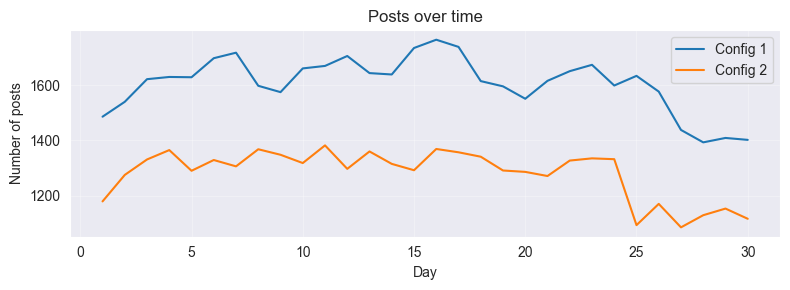

In [11]:
days_1 = np.arange(1, len(posts_daily_1) + 1)
days_2 = np.arange(1, len(posts_daily_2) + 1)

plt.figure(figsize=(8, 3))

plt.plot(days_1, posts_daily_1, label='Config 1')
plt.plot(days_2, posts_daily_2, label='Config 2')

plt.xlabel('Day')
plt.ylabel('Number of posts')
plt.title('Posts over time')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
follows_daily_1 = create_counts_daily(follow_1[follow_1['action'] == 'follow'])
follows_daily_2 = create_counts_daily(follow_2[follow_2['action'] == 'follow'])

Rounds: 720
Days: 30.0
Rounds: 721
Days: 30.041666666666668


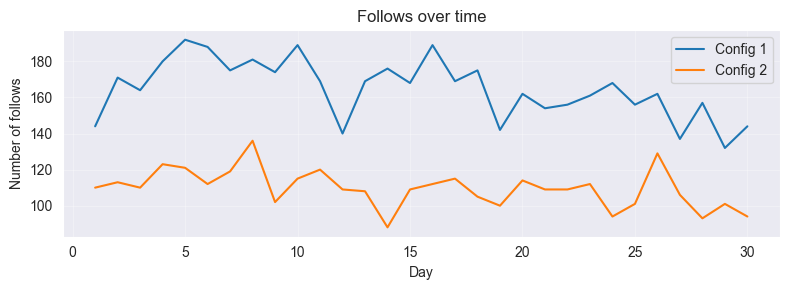

In [13]:
plt.figure(figsize=(8, 3))

plt.plot(days_1, follows_daily_1, label='Config 1')
plt.plot(days_2, follows_daily_2, label='Config 2')

plt.xlabel('Day')
plt.ylabel('Number of follows')
plt.title('Follows over time')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Rounds: 720
Days: 30.0
Rounds: 714
Days: 29.75


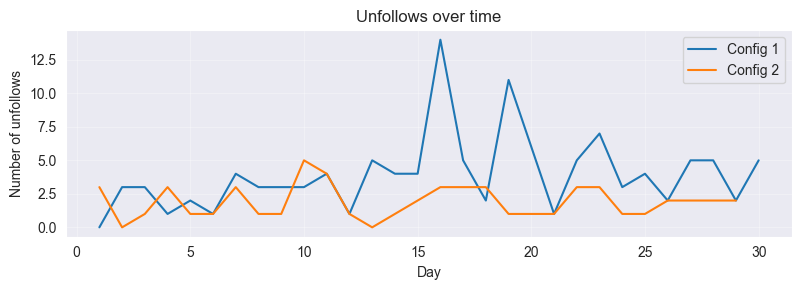

In [14]:
unfollows_daily_1 = create_counts_daily(follow_1[follow_1['action'] == 'unfollow'])
unfollows_daily_2 = create_counts_daily(follow_2[follow_2['action'] == 'unfollow'])

days_1 = np.arange(1, len(unfollows_daily_1) + 1)
days_2 = np.arange(1, len(unfollows_daily_2) + 1)

plt.figure(figsize=(8, 3))

plt.plot(days_1, unfollows_daily_1, label='Config 1')
plt.plot(days_2, unfollows_daily_2, label='Config 2')

plt.xlabel('Day')
plt.ylabel('Number of unfollows')
plt.title('Unfollows over time')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()